In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.read_csv('data/sentiment_data.csv', usecols=['Comment', 'Sentiment'])
df.head()

,Comment,Sentiment
0,lets forget apple pay required brand new iphon...,1
1,nz retailers don’t even contactless credit car...,0
2,forever acknowledge channel help lessons ideas...,2
3,whenever go place doesn’t take apple pay doesn...,0
4,apple pay convenient secure easy use used kore...,2


In [3]:
df.shape

(241145, 2)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 241145 entries, 0 to 241144
Data columns (total 2 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Comment    240928 non-null  object
 1   Sentiment  241145 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 3.7+ MB


In [5]:
df[df.duplicated(keep=False)].sort_values(by=df.columns.to_list()).head(6)

,Comment,Sentiment
42989,aaa new follower hiii,1
66629,aaa new follower hiii,1
41630,aaaa cant go pagee really exist,1
51818,aaaa cant go pagee really exist,1
33218,aaaaaaaaaaa mcfly,1
61010,aaaaaaaaaaa mcfly,1


In [6]:
df = df.drop_duplicates(keep='first')

In [7]:
df[df.isnull().any(axis=1)]

,Comment,Sentiment
1014,NaN,1
7414,NaN,2
21505,NaN,0


In [8]:
df = df.dropna(subset=['Comment'])

In [9]:
df.describe()

,Sentiment
count,214333.000000
mean,1.214339
std,0.786895
min,0.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,2.000000


# **Data Visualisation**

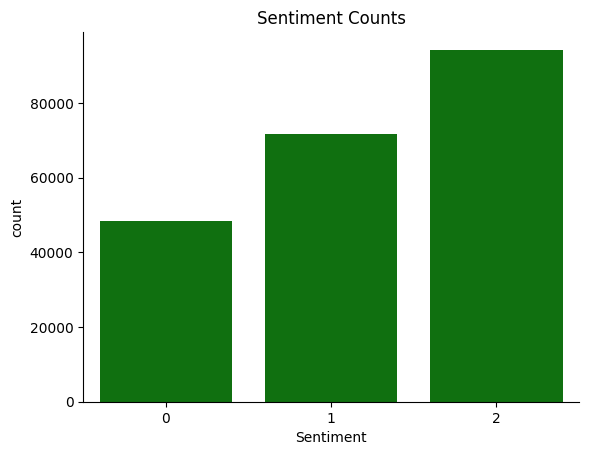

In [10]:
sns.countplot(data=df, x='Sentiment', color='green')
plt.title('Sentiment Counts')
sns.despine()
plt.show()

In [11]:
df['Text Length'] = df['Comment'].apply(lambda x: len(x.split()))
print(df['Text Length'].describe())

count    214333.000000
mean         13.705645
std          10.430138
min           1.000000
25%           7.000000
50%          12.000000
75%          19.000000
max         742.000000
Name: Text Length, dtype: float64


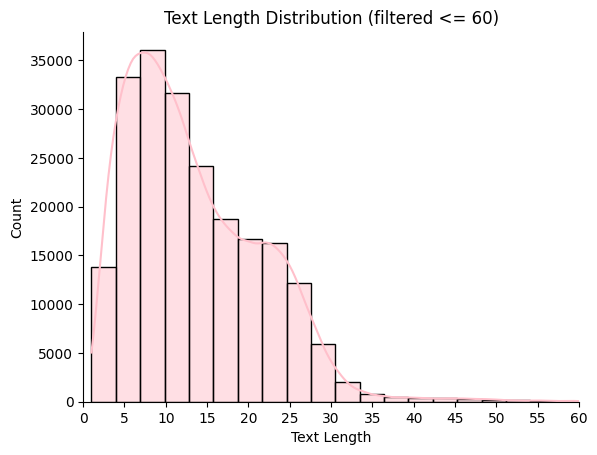

In [12]:
df_filtered = df[df['Text Length'] <= 60]
sns.histplot(data=df_filtered, x='Text Length', bins=20, color='pink', kde=True)
plt.title('Text Length Distribution (filtered <= 60)')
plt.xlim(0, 60)
plt.xticks(range(0, 61, 5))
sns.despine()
plt.show()

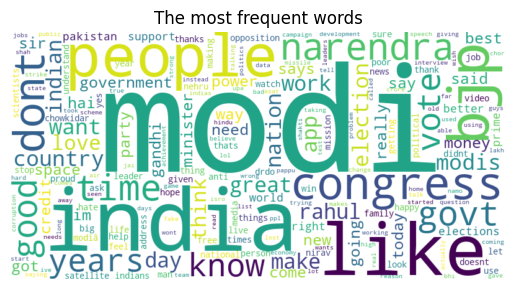

In [13]:
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud

vectorizer = CountVectorizer(stop_words='english', max_features=1000)
X = vectorizer.fit_transform(df['Comment'])

word_freq = dict(zip(vectorizer.get_feature_names_out(), X.sum(axis=0).tolist()[0]))
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_freq)

plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('The most frequent words')
plt.show()

# **Predictive Modelling**

In [15]:
import nltk
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    tokens = text.split()
    lemmatized = [lemmatizer.lemmatize(token) for token in tokens]
    return ' '.join(lemmatized)

df['Lemmatized Comment'] = df['Comment'].apply(lemmatize_text)

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\42060\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\42060\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [27]:
from sklearn.model_selection import train_test_split

X = df['Lemmatized Comment']
y = df['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.6, stratify=y, random_state=42)

## **1. Logistic Regression**

In [28]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

model = Pipeline(steps=[
    ('tfidf', TfidfVectorizer()),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))
])
model.fit(X_train, y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer()),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

Accuracy: 0.78
Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.74      0.72     28986
           1       0.73      0.82      0.77     43063
           2       0.87      0.76      0.81     56551

    accuracy                           0.78    128600
   macro avg       0.77      0.77      0.77    128600
weighted avg       0.78      0.78      0.78    128600



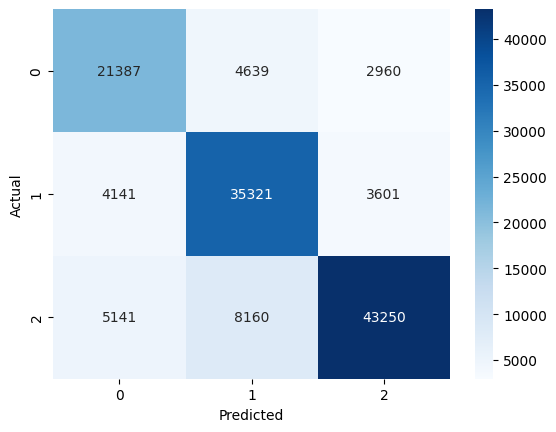

In [29]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
cr = classification_report(y_test, y_pred)

print(f'Accuracy: {acc:.2f}')
print(f'Classification Report:\n{cr}')

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## **2. Multinomial Naive Bayes**

### **a) basic**

In [49]:
from sklearn.naive_bayes import MultinomialNB

model = Pipeline(steps=[
    ('tfidf', TfidfVectorizer()),
    ('nb', MultinomialNB())
])
model.fit(X_train, y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer()), ('nb', MultinomialNB())])

Accuracy: 0.53
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.12      0.21     28986
           1       0.74      0.24      0.36     43063
           2       0.49      0.97      0.65     56551

    accuracy                           0.53    128600
   macro avg       0.70      0.44      0.41    128600
weighted avg       0.66      0.53      0.45    128600



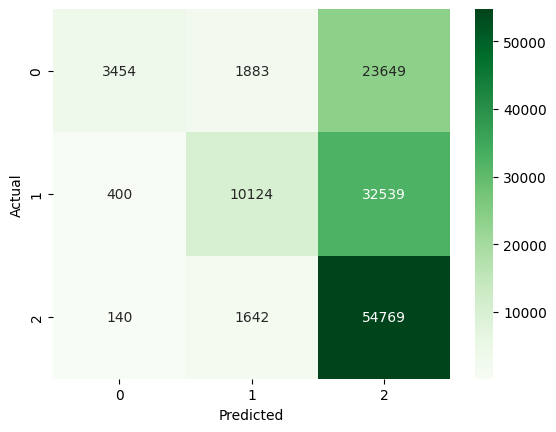

In [52]:
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
cr = classification_report(y_test, y_pred)

print(f'Accuracy: {acc:.2f}')
print(f'Classification Report:\n{cr}')

sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### **b) TfIdf tuning**

In [53]:
model = Pipeline(steps=[
    ('tfidf', TfidfVectorizer(max_features=10000,
        ngram_range=(1,2),
        sublinear_tf=True)),
    ('nb', MultinomialNB())
])
model.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=10000, ngram_range=(1, 2),
                                 sublinear_tf=True)),
                ('nb', MultinomialNB())])

Accuracy: 0.66
Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.44      0.55     28986
           1       0.67      0.57      0.61     43063
           2       0.64      0.84      0.72     56551

    accuracy                           0.66    128600
   macro avg       0.68      0.62      0.63    128600
weighted avg       0.67      0.66      0.65    128600



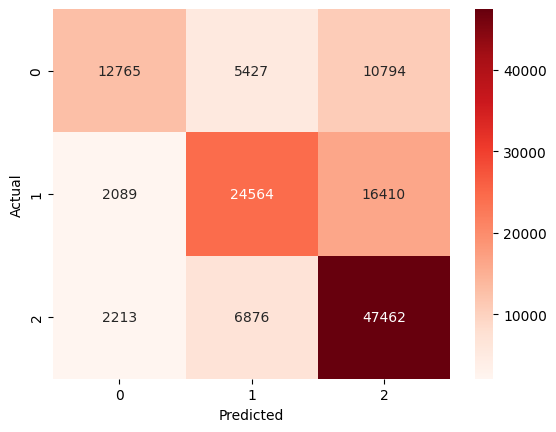

In [54]:
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
cr = classification_report(y_test, y_pred)

print(f'Accuracy: {acc:.2f}')
print(f'Classification Report:\n{cr}')

sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## **3. Linear SVC**

In [56]:
from sklearn.svm import LinearSVC

model = Pipeline(steps=[
    ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1,2), sublinear_tf=True)),
    ('svc', LinearSVC(class_weight='balanced', max_iter=5000))
])
model.fit(X_train, y_train)

C:\Users\42060\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=10000, ngram_range=(1, 2),
                                 sublinear_tf=True)),
                ('svc', LinearSVC(class_weight='balanced', max_iter=5000))])

Accuracy: 0.77
Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.70      0.71     28986
           1       0.73      0.81      0.77     43063
           2       0.85      0.78      0.81     56551

    accuracy                           0.77    128600
   macro avg       0.76      0.76      0.76    128600
weighted avg       0.78      0.77      0.77    128600



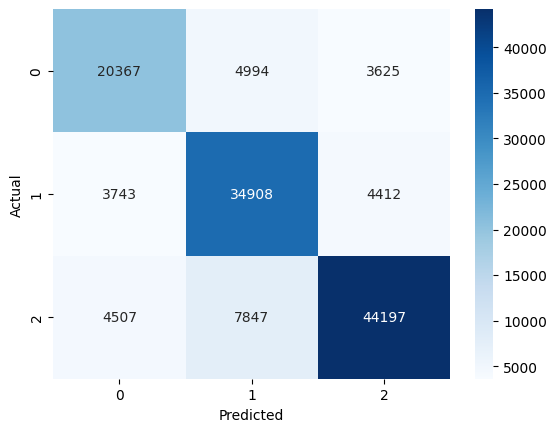

In [57]:
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
cr = classification_report(y_test, y_pred)

print(f'Accuracy: {acc:.2f}')
print(f'Classification Report:\n{cr}')

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## **4. XGBoost**

In [62]:
from xgboost import XGBClassifier

model = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1,2), sublinear_tf=True)),
    ('xgb', XGBClassifier(objective='multi:softmax', num_class=3, learning_rate=0.1, n_estimators=500, eval_metric='mlogloss', random_state=42))
])
model.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=10000, ngram_range=(1, 2),
                                 sublinear_tf=True)),
                ('xgb',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='mlogloss',
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=500, n_jobs=None, num_class=3, ...))])

Accuracy: 0.78
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.58      0.68     28986
           1       0.70      0.88      0.78     43063
           2       0.84      0.80      0.82     56551

    accuracy                           0.78    128600
   macro avg       0.79      0.75      0.76    128600
weighted avg       0.79      0.78      0.77    128600



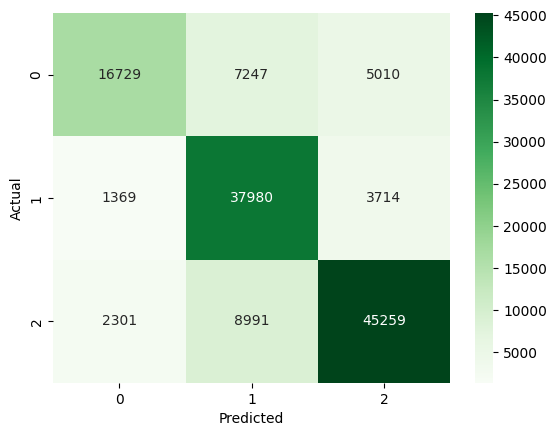

In [63]:
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
cr = classification_report(y_test, y_pred)

print(f'Accuracy: {acc:.2f}')
print(f'Classification Report:\n{cr}')

sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

To be continued.